# 1. Environment and Data Setup

Install dependencies, download datasets, and prepare folder structure.

In [1]:
# 1. Install necessary libraries for cloud training
!pip install gdown optuna tqdm scikit-learn

# 2. Download the IND dataset and name it IND.zip
!gdown "1ESX2cEQFyTagBqxHFzP2q5USmrKhA0nd" -O IND.zip

# 3. Download the CNT_SEG dataset and name it CNT_SEG.zip
!gdown "1sTXHjhwDVOcSeo5Yd8O3WV8cm7V5ZgP7" -O CNT_SEG.zip

# 4. Create a data folder and unzip both datasets into it
!mkdir -p ./data/
!unzip -o IND.zip -d ./data/IND/
!unzip -o CNT_SEG.zip -d ./data/CNT_SEG/

print("✅ All datasets downloaded and extracted successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 5.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 61.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.9/263.9 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 30.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 49.6 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 82.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.1/615.1 kB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 10.4 MB/s eta 0:00:00
Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may

In [1]:
!mv ./data/IND/IND/* ./data/IND/
!mv ./data/CNT_SEG/CNT_SEG/* ./data/CNT_SEG/

'mv' is not recognized as an internal or external command,
operable program or batch file.
'mv' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
import sys
!{sys.executable} -m pip install scikit-learn
!{sys.executable} -m pip install matplotlib

  Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (8.9 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.2 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


# 2. Dataset Definition and Time Length

Define dataset class and compute target sequence length from IND data.

In [1]:
import glob
import os
import numpy as np
import torch
from torch.utils.data import Dataset

class UnifiedNPYDataset(Dataset):
    def __init__(
        self,
        base_path,
        target_T,
        cases=("case1",),
        use_ind=True,
        use_cnt=True,
        include_anomaly=True,
        stride_ratio=5.0,
    ):
        self.samples = []  # (path, start, label)
        self.target_T = target_T
        self.stride = int(target_T * stride_ratio)
        self.rng = np.random.default_rng(42)

        ind_normal_samples = []
        ind_anom_samples = []
        cnt_candidates = []

        dropped_short = 0

        for case in cases:
            if use_ind:
                normal_dir = os.path.join(base_path, "IND", case, "normal")
                for p in glob.glob(os.path.join(normal_dir, "*.npy")):
                    x = np.load(p, mmap_mode="r")
                    T = x.shape[-1]
                    if T < target_T:
                        dropped_short += 1
                        continue
                    ind_normal_samples.append((p, None, 0))

            if use_ind and include_anomaly:
                anom_dir = os.path.join(base_path, "IND", case, "anomaly")
                for p in glob.glob(os.path.join(anom_dir, "*.npy")):
                    x = np.load(p, mmap_mode="r")
                    T = x.shape[-1]
                    if T < target_T:
                        dropped_short += 1
                        continue
                    ind_anom_samples.append((p, None, 1))

            if use_cnt:
                cnt_seg_dir = os.path.join(base_path, "CNT_SEG", case)
                cnt_dir = os.path.join(base_path, "CNT", case)

                if os.path.isdir(cnt_seg_dir):
                    cnt_paths = glob.glob(os.path.join(cnt_seg_dir, "*.npy"))
                else:
                    seg_paths = glob.glob(os.path.join(cnt_dir, "*_seg*.npy"))
                    cnt_paths = seg_paths if len(seg_paths) > 0 else glob.glob(os.path.join(cnt_dir, "*.npy"))

                for p in cnt_paths:
                    x = np.load(p, mmap_mode="r")
                    T = x.shape[-1]
                    if T < target_T:
                        dropped_short += 1
                        continue
                    for start in range(0, T - target_T + 1, self.stride):
                        cnt_candidates.append((p, start, 0))

        if use_ind:
            self.samples.extend(ind_normal_samples)

        sampled_cnt = []
        if use_cnt:
            target_cnt = len(ind_normal_samples) if use_ind else len(cnt_candidates)
            if target_cnt > 0 and len(cnt_candidates) > 0:
                if len(cnt_candidates) >= target_cnt:
                    pick_idx = self.rng.choice(len(cnt_candidates), size=target_cnt, replace=False)
                    sampled_cnt = [cnt_candidates[i] for i in pick_idx]
                else:
                    sampled_cnt = cnt_candidates
                    print(f"[WARN] CNT candidates ({len(cnt_candidates)}) < target ({target_cnt})")
                self.samples.extend(sampled_cnt)

        if use_ind and include_anomaly:
            self.samples.extend(ind_anom_samples)

        print(f"[INFO] IND normal: {len(ind_normal_samples)}")
        print(f"[INFO] CNT candidates (windows): {len(cnt_candidates)}")
        print(f"[INFO] CNT sampled: {len(sampled_cnt)}")
        print(f"[INFO] IND anomaly: {len(ind_anom_samples)}")
        print(f"[WARN] Dropped short samples (< target_T): {dropped_short}")
        print(f"[INFO] Total samples: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, start, label = self.samples[idx]
        x = np.load(path, mmap_mode="r")

        if start is None:
            T = x.shape[-1]
            start = self.rng.integers(0, T - self.target_T + 1)

        x = x[:, :, start:start + self.target_T]
        return torch.from_numpy(x.copy()).float(), label

In [2]:
def compute_target_T_from_npy(base_path, cases, max_samples=100):
    Ts = []

    for case in cases:
        normal_dir = os.path.join(base_path, "IND", case, "normal")
        paths = glob.glob(os.path.join(normal_dir, "*.npy"))

        for p in paths[:max_samples]:
            x = np.load(p)
            Ts.append(x.shape[-1])

    target_T = int(np.median(Ts))
    print(f"[INFO] target_T from IND: {target_T}")
    print(f"[INFO] min={min(Ts)}, max={max(Ts)}")
    return target_T

base_npy_path = "./data"
target_T = compute_target_T_from_npy(
    base_path=base_npy_path,
    cases=["case1", "case2", "case3", "case4"]
)

npy_dataset = UnifiedNPYDataset(
    base_path=base_npy_path,
    cases=["case1", "case2", "case3", "case4"],
    target_T=target_T,
    use_ind=True,
    use_cnt=True,
    include_anomaly=True,
    stride_ratio=5.0,
 )
print(len(npy_dataset), target_T)

[INFO] target_T from IND: 582
[INFO] min=582, max=582
[INFO] IND normal: 5400
[INFO] CNT candidates (windows): 15678
[INFO] CNT sampled: 5400
[INFO] IND anomaly: 1058
[WARN] Dropped short samples (< target_T): 1
[INFO] Total samples: 11858
11858 582


# 3. Train/Validation/Test Split

Split normal and anomaly samples into training and evaluation subsets.

In [ ]:
import random
from torch.utils.data import Subset

random.seed(42)

# Separate indices
normal_indices = [i for i, (_, _, y) in enumerate(npy_dataset.samples) if y == 0]
anom_indices   = [i for i, (_, _, y) in enumerate(npy_dataset.samples) if y == 1]

# split normal into IND / CNT
ind_indices = [i for i in normal_indices if npy_dataset.samples[i][1] is None]
cnt_indices = [i for i in normal_indices if npy_dataset.samples[i][1] is not None]

# Shuffle separately
random.shuffle(ind_indices)
random.shuffle(cnt_indices)

# Split function
def split_indices(indices):
    n = len(indices)
    train = indices[:int(0.8 * n)]
    val   = indices[int(0.8 * n):int(0.9 * n)]
    test  = indices[int(0.9 * n):]
    return train, val, test

# Stratified split
ind_train, ind_val, ind_test = split_indices(ind_indices)
cnt_train, cnt_val, cnt_test = split_indices(cnt_indices)

# merge back
train_idx        = ind_train + cnt_train
val_normal_idx   = ind_val + cnt_val
test_normal_idx  = ind_test + cnt_test

# shuffle merged splits
random.shuffle(train_idx)
random.shuffle(val_normal_idx)
random.shuffle(test_normal_idx)

# ANOMALY split (50 / 50)
random.shuffle(anom_indices)

m = len(anom_indices)
val_anom_idx  = anom_indices[:m // 2]
test_anom_idx = anom_indices[m // 2:]

# DATASETS
train_dataset = Subset(npy_dataset, train_idx)

val_normal = Subset(npy_dataset, val_normal_idx)
val_anom   = Subset(npy_dataset, val_anom_idx)

test_normal = Subset(npy_dataset, test_normal_idx)
test_anom   = Subset(npy_dataset, test_anom_idx)

# 4. LSTM Autoencoder Model

Define model architecture and reconstruction scoring function.

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import average_precision_score

if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("[INFO] device:", device)

def to_seq(x):
    b, c, m, t = x.shape
    seq = x.permute(0, 3, 1, 2).contiguous().reshape(b, t, c * m)
    return seq, (b, c, m, t)

def from_seq(seq, shape):
    b, c, m, t = shape
    return seq.reshape(b, t, c, m).permute(0, 2, 3, 1).contiguous()

class LSTMAutoEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=256, latent_dim=128, num_layers=2, dropout=0.2):
        super().__init__()
        self.encoder = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.to_latent = nn.Linear(hidden_dim, latent_dim)
        self.latent_activation = nn.Tanh()
        self.from_latent = nn.Linear(latent_dim, hidden_dim)
        self.decoder = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.output_proj = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        seq, shape = to_seq(x)
        _, (h_n, _) = self.encoder(seq)
        h_last = h_n[-1]
        z = self.latent_activation(self.to_latent(h_last))
        dec_seed = self.from_latent(z)

        t = seq.size(1)
        dec_in = dec_seed.unsqueeze(1).repeat(1, t, 1)
        dec_out, _ = self.decoder(dec_in)
        recon_seq = self.output_proj(dec_out)
        recon = from_seq(recon_seq, shape)
        return recon

def reconstruction_errors(model, loader):
    model.eval()
    scores = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            recon = model(x)
            err = torch.mean(torch.abs(x - recon), dim=(1, 2, 3))
            scores.extend(err.detach().cpu().numpy())
    return np.array(scores)

[INFO] device: cuda


# 5. DataLoaders and Case Scopes

Build train/validation/test loaders and per-case evaluation scopes.

In [ ]:
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from collections import Counter
import random

# CASE MAPPING
def infer_case_from_path(path: str) -> str:
    parts = path.replace("\\", "/").split("/")
    if "IND" in parts:
        ind_pos = parts.index("IND")
        if ind_pos + 1 < len(parts):
            return parts[ind_pos + 1]
    return "unknown"

sample_cases = [infer_case_from_path(p) for (p, _, _) in npy_dataset.samples]

# TRAIN LOADER (NORMAL ONLY)
train_samples = [npy_dataset.samples[i] for i in train_idx]
labels = ["IND" if start is None else "CNT" for (_, start, _) in train_samples]

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# VALIDATION LOADERS
def make_val_loaders(selected_cases, batch_size=8, anom_ratio=0.05):
    selected_cases = set(selected_cases)

    # NORMAL (VAL)
    sel_val_normal_idx = [
        i for i in val_normal_idx
        if sample_cases[i] in selected_cases
    ]

    # ANOMALY (VAL ONLY)
    sel_val_anom_idx = [
        i for i in val_anom_idx
        if sample_cases[i] in selected_cases
    ]

    # Downsample anomalies
    n_normal = len(sel_val_normal_idx)
    target_anom = max(1, int(n_normal * anom_ratio))

    if len(sel_val_anom_idx) > target_anom:
        sel_val_anom_idx = random.sample(sel_val_anom_idx, target_anom)
 
    # Build subsets
    val_normal_subset = Subset(npy_dataset, sel_val_normal_idx)
    val_anom_subset   = Subset(npy_dataset, sel_val_anom_idx)

    val_normal_loader = DataLoader(val_normal_subset, batch_size=batch_size, shuffle=False)
    val_anom_loader   = DataLoader(val_anom_subset, batch_size=batch_size, shuffle=False)

    return val_normal_loader, val_anom_loader, len(sel_val_normal_idx), len(sel_val_anom_idx)

def make_test_loaders(selected_cases, batch_size=8, anom_ratio=0.05):
    selected_cases = set(selected_cases)

    # NORMAL (TEST)
    sel_test_normal_idx = [
        i for i in test_normal_idx
        if sample_cases[i] in selected_cases
    ]

    # ANOMALY (TEST)
    sel_test_anom_idx = [
        i for i in test_anom_idx
        if sample_cases[i] in selected_cases
    ]

    # Downsample anomalies (same as val)
    n_normal = len(sel_test_normal_idx)
    target_anom = max(1, int(n_normal * anom_ratio))

    if len(sel_test_anom_idx) > target_anom:
        sel_test_anom_idx = random.sample(sel_test_anom_idx, target_anom)

    # Build subsets
    test_normal_subset = Subset(npy_dataset, sel_test_normal_idx)
    test_anom_subset   = Subset(npy_dataset, sel_test_anom_idx)

    test_normal_loader = DataLoader(test_normal_subset, batch_size=batch_size, shuffle=False)
    test_anom_loader   = DataLoader(test_anom_subset, batch_size=batch_size, shuffle=False)

    return test_normal_loader, test_anom_loader, len(sel_test_normal_idx), len(sel_test_anom_idx)

# CASE SCOPES
TRAIN_CASES = ["case1", "case2", "case3", "case4"]

VAL_CASE_SCOPES = {
    "case1_only": ["case1"],
    "case2_only": ["case2"],
    "case3_only": ["case3"],
    "case4_only": ["case4"],
    "all_cases": TRAIN_CASES,
}

# VAL LOADERS
val_loaders = {}

for scope_name, scope_cases in VAL_CASE_SCOPES.items():
    vn_loader, va_loader, n_normal, n_anom = make_val_loaders(scope_cases)

    val_loaders[scope_name] = {
        "val_normal_loader": vn_loader,
        "val_anom_loader": va_loader,
        "n_normal": n_normal,
        "n_anom": n_anom,
    }

    print(f"[VAL] {scope_name}: normal={n_normal}, anomaly={n_anom}")

test_loaders = {}

for scope_name, scope_cases in VAL_CASE_SCOPES.items():
    tn_loader, ta_loader, n_normal, n_anom = make_test_loaders(scope_cases)

    test_loaders[scope_name] = {
        "test_normal_loader": tn_loader,
        "test_anom_loader": ta_loader,
        "n_normal": n_normal,
        "n_anom": n_anom,
    }

    print(f"[TEST] {scope_name}: normal={n_normal}, anomaly={n_anom}")

val_normal_loader = val_loaders["all_cases"]["val_normal_loader"]
val_anom_loader   = val_loaders["all_cases"]["val_anom_loader"]
test_normal_loader = test_loaders["all_cases"]["test_normal_loader"]
test_anom_loader   = test_loaders["all_cases"]["test_anom_loader"]

[VAL] case1_only: normal=124, anomaly=6
[VAL] case2_only: normal=144, anomaly=7
[VAL] case3_only: normal=145, anomaly=7
[VAL] case4_only: normal=127, anomaly=6
[VAL] all_cases: normal=540, anomaly=27
[TEST] case1_only: normal=145, anomaly=7
[TEST] case2_only: normal=142, anomaly=7
[TEST] case3_only: normal=123, anomaly=6
[TEST] case4_only: normal=130, anomaly=6
[TEST] all_cases: normal=540, anomaly=27


# 6. Fixed Best Hyperparameters

Set baseline best parameters tuning from Optuna (Ran Optuna on seperate code file)

In [ ]:
from torch.utils.data import DataLoader

best_params = {
    "hidden_dim": 256,
    "latent_dim": 96,
    "num_layers": 2,
    "dropout": 0.17513596367181428,
    "lr": 0.0006420218819346047,
    "weight_decay": 4.121506603185355e-07,
    "batch_size": 8,
    "loss_type": "l1",
}
print("[BEST] params (fixed):", best_params)

# 7. Optuna Tuning

In [ ]:
from torch.utils.data import DataLoader
import optuna
TUNE_SCOPE = "all_cases"
N_TRIALS = 30
TUNE_EPOCHS = 30

def objective(trial):
    hidden_dim = trial.suggest_categorical("hidden_dim", [128, 192, 256, 320])
    latent_dim = trial.suggest_categorical("latent_dim", [64, 96, 128, 160])
    num_layers = trial.suggest_int("num_layers", 1, 3)
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    lr = trial.suggest_float("lr", 1e-4, 3e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-7, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [8, 16, 32])
    loss_type = trial.suggest_categorical("loss_type", ["l1", "l2"])

    train_loader_tune = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    vn_loader_local = val_normal_loader
    va_loader_local = val_anom_loader

    x0, _ = next(iter(train_loader_tune))
    _, c, m, _ = x0.shape
    input_dim = c * m

    model = LSTMAutoEncoder(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        latent_dim=latent_dim,
        num_layers=num_layers,
        dropout=dropout,
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.L1Loss() if loss_type == "l1" else nn.MSELoss()

    for _ in range(TUNE_EPOCHS):
        model.train()
        for x, _ in train_loader_tune:
            x = x.to(device)
            recon = model(x)
            loss = criterion(recon, x)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    normal_scores = reconstruction_errors(model, vn_loader_local)
    anom_scores = reconstruction_errors(model, va_loader_local)

    y_true = np.concatenate([np.zeros(len(normal_scores)), np.ones(len(anom_scores))])
    y_score = np.concatenate([normal_scores, anom_scores])

    if len(np.unique(y_true)) < 2:
        return 0.0

    pr_auc = average_precision_score(y_true, y_score)
    gap = float(np.mean(anom_scores) - np.mean(normal_scores))
    trial.set_user_attr("gap", gap)
    trial.set_user_attr("pr_auc", float(pr_auc))
    trial.set_user_attr("loss_type", loss_type)
    return float(pr_auc)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS)
print("[BEST] PR-AUC:", study.best_value)
print("[BEST] params:", study.best_params)

best_params = study.best_params.copy()

# 8. Rebuild Model with Best Params

Instantiate the final model configuration before full training.

In [9]:
# Step 1: rebuild model with fixed best params
hidden_dim = best_params["hidden_dim"]
latent_dim = best_params["latent_dim"]
num_layers = best_params["num_layers"]
dropout = best_params["dropout"]

sample_x, _ = next(iter(train_loader))
_, c, m, _ = sample_x.shape
input_dim = c * m

model = LSTMAutoEncoder(
    input_dim=input_dim,
    hidden_dim=hidden_dim,
    latent_dim=latent_dim,
    num_layers=num_layers,
    dropout=dropout,
).to(device)

# 9. Final Training

Train with selected parameters and monitor train/validation loss.

In [ ]:
FINAL_EPOCHS = 50

best = best_params.copy()
batch_size = best["batch_size"]
loss_type = best["loss_type"]

train_loader_final = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
x0, _ = next(iter(train_loader_final))
_, c, m, _ = x0.shape
input_dim = c * m

best_model = LSTMAutoEncoder(
    input_dim=input_dim,
    hidden_dim=best["hidden_dim"],
    latent_dim=best["latent_dim"],
    num_layers=best["num_layers"],
    dropout=best["dropout"],
).to(device)

optimizer = torch.optim.AdamW(
    best_model.parameters(),
    lr=best["lr"],
    weight_decay=best["weight_decay"],
)
criterion = nn.L1Loss() if loss_type == "l1" else nn.MSELoss()
print(f"[INFO] Final loss: {loss_type.upper()}")

# Track both curves for plotting
train_loss_hist = []
val_loss_hist = []

for epoch in range(FINAL_EPOCHS):
    best_model.train()
    total_train_loss = 0.0
    for x, _ in train_loader_final:
        x = x.to(device)
        recon = best_model(x)
        loss = criterion(recon, x)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader_final)
    train_loss_hist.append(avg_train_loss)

    # Validation loss (normal validation set)
    best_model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for x, _ in val_normal_loader:
            x = x.to(device)
            recon = best_model(x)
            total_val_loss += criterion(recon, x).item()

    avg_val_loss = total_val_loss / len(val_normal_loader)
    val_loss_hist.append(avg_val_loss)

    print(f"[FINAL TRAIN] epoch={epoch+1}/{FINAL_EPOCHS} train={avg_train_loss:.6f} val={avg_val_loss:.6f}")

def eval_current_loaders(model):
    normal_scores = reconstruction_errors(model, test_normal_loader)
    anom_scores = reconstruction_errors(model, test_anom_loader)

    y_true = np.concatenate([np.zeros(len(normal_scores)), np.ones(len(anom_scores))])
    y_score = np.concatenate([normal_scores, anom_scores])

    pr_auc = average_precision_score(y_true, y_score) if len(np.unique(y_true)) == 2 else float("nan")
    gap = float(np.mean(anom_scores) - np.mean(normal_scores))
    threshold = float(np.percentile(normal_scores, 95)) if len(normal_scores) > 0 else float("nan")
    recall = float(np.mean(anom_scores > threshold)) if len(anom_scores) > 0 and not np.isnan(threshold) else float("nan")

    return {
        "n_normal": len(normal_scores),
        "n_anom": len(anom_scores),
        "pr_auc": pr_auc,
        "gap": gap,
        "threshold95": threshold,
        "anom_recall": recall,
    }

result = eval_current_loaders(best_model)
print(
    f"[TEST] n_normal={result['n_normal']} n_anom={result['n_anom']} "
    f"PR-AUC={result['pr_auc']:.4f} GAP={result['gap']:.6f} "
    f"THR95={result['threshold95']:.6f} RECALL={result['anom_recall']:.4f}"
)

[INFO] Final loss: L1
[FINAL TRAIN] epoch=1/50 train=0.062802 val=0.055227
[FINAL TRAIN] epoch=2/50 train=0.047904 val=0.047842
[FINAL TRAIN] epoch=3/50 train=0.044348 val=0.046785
[FINAL TRAIN] epoch=4/50 train=0.042498 val=0.043428
[FINAL TRAIN] epoch=5/50 train=0.041477 val=0.040810
[FINAL TRAIN] epoch=6/50 train=0.041241 val=0.041347
[FINAL TRAIN] epoch=7/50 train=0.040423 val=0.039298
[FINAL TRAIN] epoch=8/50 train=0.039087 val=0.039168
[FINAL TRAIN] epoch=9/50 train=0.038330 val=0.038918
[FINAL TRAIN] epoch=10/50 train=0.037705 val=0.039211
[FINAL TRAIN] epoch=11/50 train=0.037771 val=0.039683
[FINAL TRAIN] epoch=12/50 train=0.037596 val=0.038839
[FINAL TRAIN] epoch=13/50 train=0.037250 val=0.039842
[FINAL TRAIN] epoch=14/50 train=0.037288 val=0.039724
[FINAL TRAIN] epoch=15/50 train=0.037534 val=0.038485
[FINAL TRAIN] epoch=16/50 train=0.037062 val=0.038753
[FINAL TRAIN] epoch=17/50 train=0.036925 val=0.038681
[FINAL TRAIN] epoch=18/50 train=0.037177 val=0.038609
[FINAL TRAIN] e

# 10. Loss Curve Visualization

Plot training and validation loss trajectories.

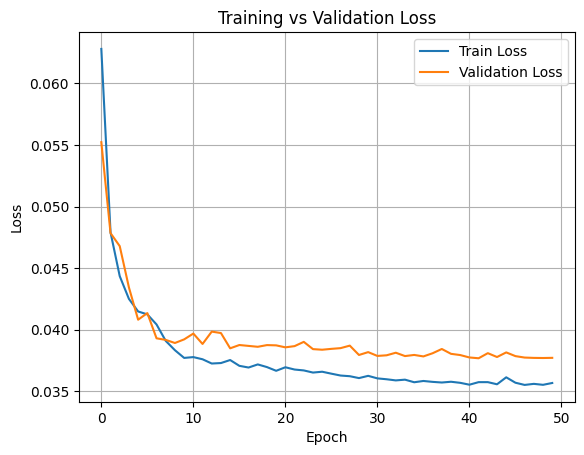

In [13]:
import matplotlib.pyplot as plt

if "train_loss_hist" not in globals() or "val_loss_hist" not in globals():
    print("Run Cell 8 first to generate train_loss_hist and val_loss_hist.")
else:
    plt.figure()
    plt.plot(train_loss_hist, label="Train Loss")
    plt.plot(val_loss_hist, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid()
    plt.show()

# 11. Validation Threshold Selection

Compute best threshold on validation scores.

In [14]:
# Step 3: compute validation threshold (F1)
from sklearn.metrics import precision_recall_curve

def get_scores(loader):
    best_model.eval()
    scores = []
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(device)
            recon = best_model(x)

            if best_params["loss_type"] == "l1":
                err = torch.mean(torch.abs(x - recon), dim=(1, 2, 3))
            else:
                err = torch.mean((x - recon) ** 2, dim=(1, 2, 3))

            scores.extend(err.cpu().numpy())
    return np.array(scores)

# validation scores
val_normal_scores = get_scores(val_normal_loader)
val_anom_scores = get_scores(val_anom_loader)

y_true = np.concatenate([
    np.zeros(len(val_normal_scores)),
    np.ones(len(val_anom_scores))
])
y_score = np.concatenate([val_normal_scores, val_anom_scores])

precision, recall, thresholds = precision_recall_curve(y_true, y_score)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

best_idx = np.argmax(f1[:-1])
best_threshold = thresholds[best_idx]

print("Best threshold:", best_threshold)

Best threshold: 0.04237468


# 12. Per-Case Test Evaluation

Report PR-AUC, F1, and error gap for each case scope.

In [15]:
from sklearn.metrics import f1_score, average_precision_score

print("\n=== Per-case Test Results ===")

all_normal_scores = []
all_anom_scores = []

anom_ratio = 1

for scope_name, loaders in test_loaders.items():
    tn_loader = loaders["test_normal_loader"]
    ta_loader = loaders["test_anom_loader"]

    normal_scores = get_scores(tn_loader)
    anom_scores = get_scores(ta_loader)
    print(normal_scores.shape, anom_scores.shape)

    n_normal = len(normal_scores)
    target_anom = max(1, int(n_normal * anom_ratio))

    if len(anom_scores) > target_anom:
        sampled_idx = random.sample(range(len(anom_scores)), target_anom)
        anom_scores = anom_scores[sampled_idx]

    if scope_name != "all_cases":
        all_normal_scores.extend(normal_scores)
        all_anom_scores.extend(anom_scores)

    y_true = np.concatenate([
        np.zeros(len(normal_scores)),
        np.ones(len(anom_scores))
    ])
    y_score = np.concatenate([normal_scores, anom_scores])

    pr_auc = average_precision_score(y_true, y_score)
    f1 = f1_score(y_true, (y_score > best_threshold).astype(int))
    gap = anom_scores.mean() - normal_scores.mean()

    print(f"{scope_name}: PR-AUC={pr_auc:.4f}, F1={f1:.4f}, Gap={gap:.4f}")


=== Per-case Test Results ===
(145,) (7,)
case1_only: PR-AUC=0.9071, F1=0.9231, Gap=0.0094
(142,) (7,)
case2_only: PR-AUC=0.9821, F1=0.7273, Gap=0.0084
(123,) (6,)
case3_only: PR-AUC=1.0000, F1=0.7059, Gap=0.0103
(130,) (6,)
case4_only: PR-AUC=1.0000, F1=1.0000, Gap=0.0192
(540,) (27,)
all_cases: PR-AUC=0.9447, F1=0.8571, Gap=0.0108
